
# Major Project: Seasonal Agriculture Performance Analysis

## 1. Introduction to Dataset

The dataset represents agricultural activities carried out across different seasons, geographical areas and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage and economic performance.

The dataset provides students with an opportunity to explore how agricultural performance changes across seasons and to identify meaningful patterns and differences through data analysis.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 3. Objective

The objective of this project is to analyze agricultural data from different seasons to identify patterns, trends, relationships, and differences in agricultural performance.

The analysis focuses on understanding seasonal performance, environmental conditions, resource usage, crop and regional differences, and economic outcomes. The project also aims to identify unusual patterns, apply suitable statistical techniques and visualizations, interpret the results, and provide evidence-based conclusions and recommendations.

## 4. Expected Outcomes

The expected outcomes of this project are:

- Understand the structure and characteristics of seasonal agricultural data.
- Clean and prepare the dataset for analysis.
- Identify important patterns and trends in agricultural performance.
- Compare agricultural performance across different seasons, crops, and regions.
- Identify relationships and variations between agricultural variables.
- Apply suitable data analysis, statistical, and visualization techniques.
- Interpret the analysis results correctly.
- Identify important observations and unusual patterns in the dataset.
- Develop evidence-based insights and recommendations.
- Document the complete analysis in a structured notebook.

## 5. Key Questions

The analysis aims to answer the following key questions:

1. How does agricultural performance vary across different seasons?
2. What patterns and trends can be observed in the agricultural data?
3. How does resource usage vary across different seasons, crops, and irrigation methods?
4. What relationships exist between environmental conditions and agricultural performance?
5. How do economic outcomes such as revenue, cost, and profit vary across seasons?
6. Are agricultural performance patterns consistent across different regions and crop categories?
7. Are there any unusual patterns or observations in the dataset?
8. What important insights and conclusions can be obtained from the analysis?
9. How can the findings support better seasonal agricultural planning?

## 3. Loading and Understanding the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [6]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, ".", column)

Columns in the dataset:

1 . Farm_ID
2 . State
3 . District
4 . Crop
5 . Season
6 . Farm_Area_Hectares
7 . Rainfall_mm
8 . Avg_Temperature_C
9 . Humidity_pct
10 . Sunlight_Hours_Day
11 . Soil_pH
12 . Soil_Moisture_pct
13 . Nitrogen_kg_ha
14 . Phosphorus_kg_ha
15 . Potassium_kg_ha
16 . Irrigation_Method
17 . Fertilizer_kg_ha
18 . Pesticide_Litre_ha
19 . Seed_Quality_Score
20 . Yield_Tonnes_Ha
21 . Production_Tonnes
22 . Market_Price_INR_Tonne
23 . Total_Cost_INR
24 . Revenue_INR
25 . Profit_INR
26 . Water_Used_m3
27 . Water_Efficiency_t_per_1000m3
28 . Disease_Pest_Risk_pct


In [7]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 4. Data Quality Check

Before performing analysis, the dataset is checked for missing values, duplicate records and possible data quality issues. This step helps ensure that the analysis is based on clean and reliable data.

In [10]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': (missing_values / len(df)) * 100
})

missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records were found.")
else:
    print("Duplicate records were found and need to be reviewed.")

Number of duplicate records: 0
No duplicate records were found.


In [12]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\n", column)
    print("Number of unique values:", df[column].nunique())
    print(df[column].unique())


 Farm_ID
Number of unique values: 4000
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

 State
Number of unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
Number of unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
Number of unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
Number of unique values: 3
['Kharif' 'Rabi' 'Zaid']

 Irrigation_Method
Number of unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [13]:
season_count = df['Season'].value_counts()

print(season_count)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


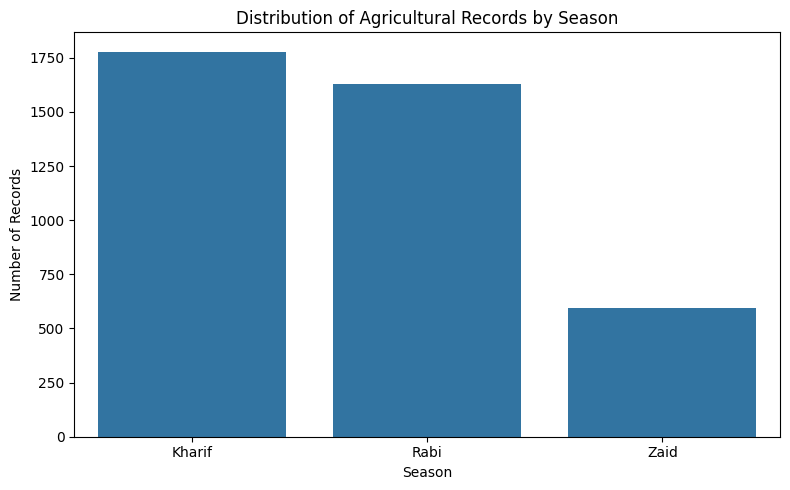

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_count.index,
    y=season_count.values
)

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

In [15]:
crop_count = df['Crop'].value_counts()

print(crop_count)

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


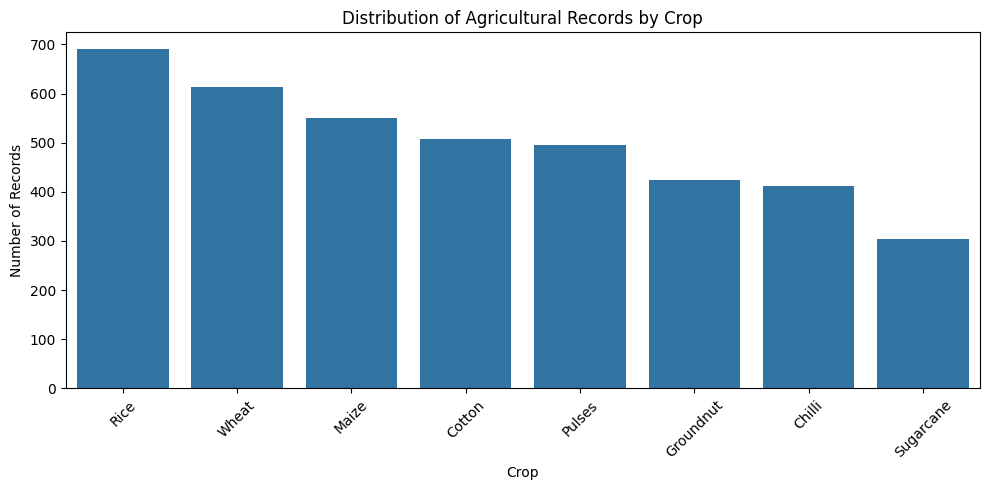

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=crop_count.index,
    y=crop_count.values
)

plt.title('Distribution of Agricultural Records by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
df.loc[df['Yield_Tonnes_Ha'] > 20, [
    'Farm_ID',
    'State',
    'District',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,7.68,36.69,281.78,556688
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,10.64,62.58,665.85,1675730
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,9.29,33.55,311.68,691166
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,2.46,49.52,121.82,279221
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,12.74,70.23,894.73,2427692
...,...,...,...,...,...,...,...,...,...
3878,SF13879,Telangana,Nalgonda,Sugarcane,Rabi,14.88,32.19,478.99,210585
3897,SF13898,Karnataka,Rajkot,Sugarcane,Zaid,14.99,31.82,476.98,706817
3940,SF13941,Madhya Pradesh,Nalgonda,Sugarcane,Zaid,2.11,35.88,75.71,130792
3966,SF13967,Maharashtra,Raichur,Sugarcane,Rabi,7.97,51.04,406.79,740757


## 5. Initial Analysis of Crop Yield

Since unusually high yield values were observed during the initial data inspection, yield performance is examined across different crops before deciding how to handle these observations.

In [18]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

crop_yield

,count,mean,median,min,max
Crop,,,,,
Sugarcane,303,46.938746,48.030,1.39,101.44
Maize,547,2.717130,2.850,0.30,6.08
Rice,682,2.439413,2.460,0.30,5.70
Wheat,612,2.109216,2.225,0.30,4.56
Chilli,407,1.540344,1.560,0.30,3.90
Groundnut,419,1.317924,1.400,0.30,3.02
Cotton,504,1.225734,1.240,0.30,2.90
Pulses,494,0.918198,0.940,0.30,2.09


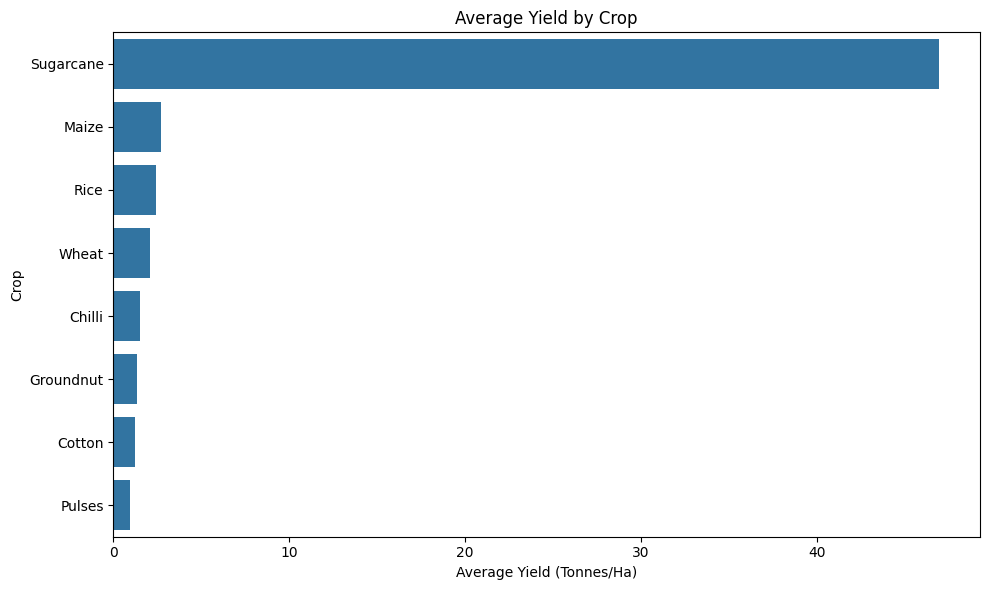

In [19]:
plt.figure(figsize=(10,6))

crop_avg_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

sns.barplot(
    x=crop_avg_yield.values,
    y=crop_avg_yield.index
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [20]:
max_yield_record = df.loc[
    df['Yield_Tonnes_Ha'].idxmax()
]

max_yield_record

,1715
Farm_ID,SF11716
State,Gujarat
District,Indore
Crop,Sugarcane
Season,Kharif
Farm_Area_Hectares,6.32
Rainfall_mm,689.0
Avg_Temperature_C,29.6
Humidity_pct,68.2
Sunlight_Hours_Day,5.9


In [21]:
print("Maximum Yield:", df['Yield_Tonnes_Ha'].max(), "Tonnes/Ha")
print("Crop:", max_yield_record['Crop'])
print("Season:", max_yield_record['Season'])
print("State:", max_yield_record['State'])
print("District:", max_yield_record['District'])
print("Farm Area:", max_yield_record['Farm_Area_Hectares'], "Hectares")
print("Production:", max_yield_record['Production_Tonnes'], "Tonnes")

Maximum Yield: 101.44 Tonnes/Ha
Crop: Sugarcane
Season: Kharif
State: Gujarat
District: Indore
Farm Area: 6.32 Hectares
Production: 641.1 Tonnes


In [22]:
df['Calculated_Production'] = (
    df['Farm_Area_Hectares'] * df['Yield_Tonnes_Ha']
)

df['Production_Difference'] = (
    df['Production_Tonnes'] - df['Calculated_Production']
)

df[['Farm_Area_Hectares',
   'Yield_Tonnes_Ha',
   'Production_Tonnes',
   'Calculated_Production',
   'Production_Difference']].head(10)

,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Calculated_Production,Production_Difference
0,0.53,2.46,1.30,1.3038,-3.800000e-03
1,6.53,0.30,1.96,1.9590,1.000000e-03
2,4.86,0.52,2.53,2.5272,2.800000e-03
3,4.50,1.84,8.28,8.2800,-1.776357e-15
4,4.21,2.21,9.30,9.3041,-4.100000e-03
5,5.46,0.72,3.93,3.9312,-1.200000e-03
6,8.13,2.53,20.57,20.5689,1.100000e-03
7,5.34,1.18,6.30,6.3012,-1.200000e-03
8,6.98,1.53,10.68,10.6794,6.000000e-04
9,13.69,2.29,31.35,31.3501,-1.000000e-04


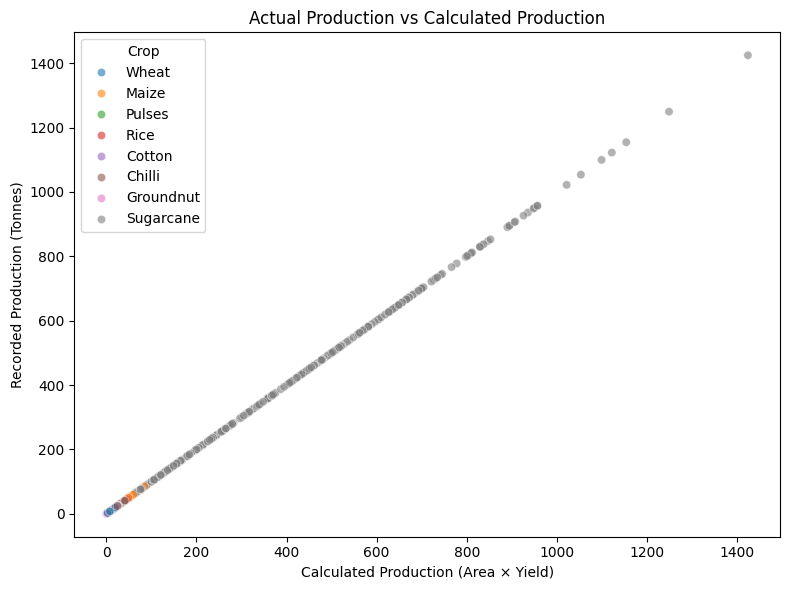

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Calculated_Production',
    y='Production_Tonnes',
    hue='Crop',
    alpha=0.6
)

plt.title('Actual Production vs Calculated Production')
plt.xlabel('Calculated Production (Area × Yield)')
plt.ylabel('Recorded Production (Tonnes)')

plt.tight_layout()
plt.show()

## 6. Data Cleaning and Preparation

After understanding the structure and characteristics of the dataset, the data is prepared for further analysis. Missing values and duplicate records are examined carefully while preserving valid agricultural observations.

In [24]:
data = df.copy()

print("Original dataset shape:", data.shape)

Original dataset shape: (4000, 30)


In [25]:
duplicate_count = data.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [26]:
missing_yield = data[data['Yield_Tonnes_Ha'].isnull()]

print("Number of records with missing yield:", len(missing_yield))

missing_yield[[
    'Farm_ID',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Production_Tonnes'
]]

Number of records with missing yield: 32


,Farm_ID,Crop,Season,Farm_Area_Hectares,Production_Tonnes
55,SF10056,Groundnut,Rabi,11.70,19.42
163,SF10164,Pulses,Zaid,3.55,1.06
555,SF10556,Chilli,Rabi,7.94,15.64
648,SF10649,Groundnut,Rabi,6.14,8.66
650,SF10651,Maize,Rabi,13.23,11.77
777,SF10778,Cotton,Rabi,1.83,2.42
874,SF10875,Rice,Kharif,3.15,3.87
899,SF10900,Pulses,Rabi,6.65,6.38
1133,SF11134,Cotton,Kharif,10.89,15.46
1251,SF11252,Chilli,Zaid,9.92,12.20


In [27]:
data['Calculated_Yield'] = (
    data['Production_Tonnes'] / data['Farm_Area_Hectares']
)

In [28]:
missing_yield[['Farm_ID', 'Crop', 'Season',
               'Farm_Area_Hectares',
               'Production_Tonnes']].copy()

,Farm_ID,Crop,Season,Farm_Area_Hectares,Production_Tonnes
55,SF10056,Groundnut,Rabi,11.70,19.42
163,SF10164,Pulses,Zaid,3.55,1.06
555,SF10556,Chilli,Rabi,7.94,15.64
648,SF10649,Groundnut,Rabi,6.14,8.66
650,SF10651,Maize,Rabi,13.23,11.77
777,SF10778,Cotton,Rabi,1.83,2.42
874,SF10875,Rice,Kharif,3.15,3.87
899,SF10900,Pulses,Rabi,6.65,6.38
1133,SF11134,Cotton,Kharif,10.89,15.46
1251,SF11252,Chilli,Zaid,9.92,12.20


In [29]:
missing_yield_check = data[data['Yield_Tonnes_Ha'].isnull()][[
    'Farm_ID',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Production_Tonnes',
    'Calculated_Yield'
]]

missing_yield_check

,Farm_ID,Crop,Season,Farm_Area_Hectares,Production_Tonnes,Calculated_Yield
55,SF10056,Groundnut,Rabi,11.70,19.42,1.659829
163,SF10164,Pulses,Zaid,3.55,1.06,0.298592
555,SF10556,Chilli,Rabi,7.94,15.64,1.969773
648,SF10649,Groundnut,Rabi,6.14,8.66,1.410423
650,SF10651,Maize,Rabi,13.23,11.77,0.889645
777,SF10778,Cotton,Rabi,1.83,2.42,1.322404
874,SF10875,Rice,Kharif,3.15,3.87,1.228571
899,SF10900,Pulses,Rabi,6.65,6.38,0.959398
1133,SF11134,Cotton,Kharif,10.89,15.46,1.419651
1251,SF11252,Chilli,Zaid,9.92,12.20,1.229839


In [30]:
missing_rainfall = data[data['Rainfall_mm'].isnull()]

print("Number of records with missing rainfall:", len(missing_rainfall))

missing_rainfall[['State',
                  'District',
                  'Crop',
                  'Season',
                  'Rainfall_mm']]

Number of records with missing rainfall: 48


,State,District,Crop,Season,Rainfall_mm
186,Tamil Nadu,Indore,Rice,Rabi,NaN
253,Tamil Nadu,Ludhiana,Sugarcane,Zaid,NaN
271,Karnataka,Erode,Groundnut,Kharif,NaN
272,Punjab,Rajkot,Maize,Rabi,NaN
287,Gujarat,Guntur,Wheat,Rabi,NaN
408,Telangana,Raichur,Wheat,Kharif,NaN
496,Tamil Nadu,Rajkot,Pulses,Zaid,NaN
520,Gujarat,Ludhiana,Pulses,Rabi,NaN
594,Madhya Pradesh,Ludhiana,Chilli,Zaid,NaN
807,Maharashtra,Nalgonda,Pulses,Zaid,NaN


In [31]:
missing_soil = data[data['Soil_Moisture_pct'].isnull()]

print("Number of records with missing soil moisture:", len(missing_soil))

missing_soil[['State',
              'District',
              'Crop',
              'Season',
              'Soil_Moisture_pct']]

Number of records with missing soil moisture: 40


,State,District,Crop,Season,Soil_Moisture_pct
28,Tamil Nadu,Rajkot,Maize,Rabi,NaN
43,Tamil Nadu,Erode,Wheat,Rabi,NaN
121,Maharashtra,Erode,Cotton,Kharif,NaN
196,Andhra Pradesh,Raichur,Rice,Kharif,NaN
467,Tamil Nadu,Warangal,Maize,Kharif,NaN
471,Tamil Nadu,Krishna,Wheat,Kharif,NaN
573,Gujarat,Raichur,Sugarcane,Rabi,NaN
707,Gujarat,Warangal,Wheat,Rabi,NaN
792,Tamil Nadu,Ludhiana,Sugarcane,Zaid,NaN
1201,Tamil Nadu,Nashik,Sugarcane,Rabi,NaN


In [32]:
missing_summary = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data) * 100).round(2)
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8
Calculated_Production,32,0.8
Production_Difference,32,0.8


## 7. Handling Missing Values

Missing yield values are calculated using the available production and farm area information. Since production is approximately equal to farm area multiplied by yield, this method preserves the relationship between the variables.

For rainfall and soil moisture, suitable group-based median values are used to avoid replacing all missing observations with one overall value.

In [33]:
# Calculate missing yield using production and farm area

data['Yield_Tonnes_Ha'] = data['Yield_Tonnes_Ha'].fillna(
    data['Production_Tonnes'] / data['Farm_Area_Hectares']
)

print("Missing Yield values after cleaning:",
      data['Yield_Tonnes_Ha'].isnull().sum())

Missing Yield values after cleaning: 0


In [34]:
# Fill missing rainfall using the median rainfall of each season

data['Rainfall_mm'] = data['Rainfall_mm'].fillna(
    data.groupby('Season')['Rainfall_mm'].transform('median')
)

print("Missing Rainfall values after cleaning:",
      data['Rainfall_mm'].isnull().sum())

Missing Rainfall values after cleaning: 0


In [35]:
# Fill missing soil moisture using Season and Crop group medians

data['Soil_Moisture_pct'] = data['Soil_Moisture_pct'].fillna(
    data.groupby(['Season', 'Crop'])['Soil_Moisture_pct'].transform('median')
)

print("Missing Soil Moisture values after cleaning:",
      data['Soil_Moisture_pct'].isnull().sum())

Missing Soil Moisture values after cleaning: 0


In [36]:
final_missing = data.isnull().sum()

final_missing[final_missing > 0]

,0
Calculated_Production,32
Production_Difference,32


In [37]:
data = data.drop(columns=[
    'Calculated_Production',
    'Production_Difference',
    'Calculated_Yield'
])

print("Temporary validation columns removed.")
print("Final dataset shape:", data.shape)

Temporary validation columns removed.
Final dataset shape: (4000, 28)


In [38]:
print("Final dataset shape:", data.shape)
print("Duplicate records:", data.duplicated().sum())
print("Total missing values:", data.isnull().sum().sum())

Final dataset shape: (4000, 28)
Duplicate records: 0
Total missing values: 0


In [39]:
summary = pd.DataFrame({
    'Rows': [data.shape[0]],
    'Columns': [data.shape[1]],
    'Duplicate Records': [data.duplicated().sum()],
    'Missing Values': [data.isnull().sum().sum()]
})

summary

,Rows,Columns,Duplicate Records,Missing Values
0,4000,28,0,0


## 8. Seasonal Agriculture Performance Analysis

After cleaning and preparing the dataset, the next step is to analyze agricultural performance across different seasons. The analysis focuses on production, yield, economic performance and environmental conditions to identify meaningful seasonal patterns.

In [40]:
season_count = data['Season'].value_counts()

season_count

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


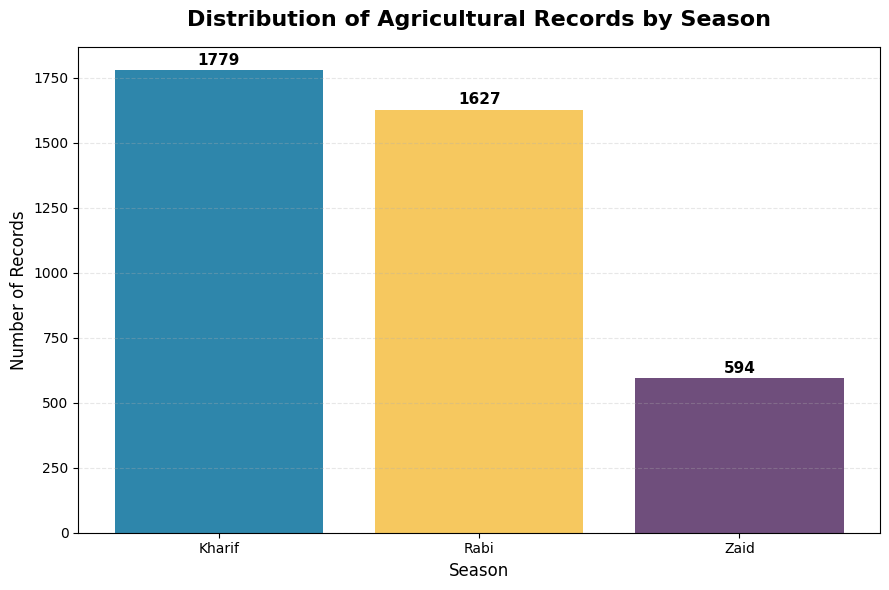

In [41]:
plt.figure(figsize=(9, 6))

colors = ['#2E86AB', '#F6C85F', '#6F4E7C']

bars = plt.bar(
    season_count.index,
    season_count.values,
    color=colors
)

plt.title(
    'Distribution of Agricultural Records by Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f'{int(height)}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.1 Average Yield Across Seasons

In [42]:
season_yield = (
    data.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628728
Rabi,5.092678
Zaid,4.633128


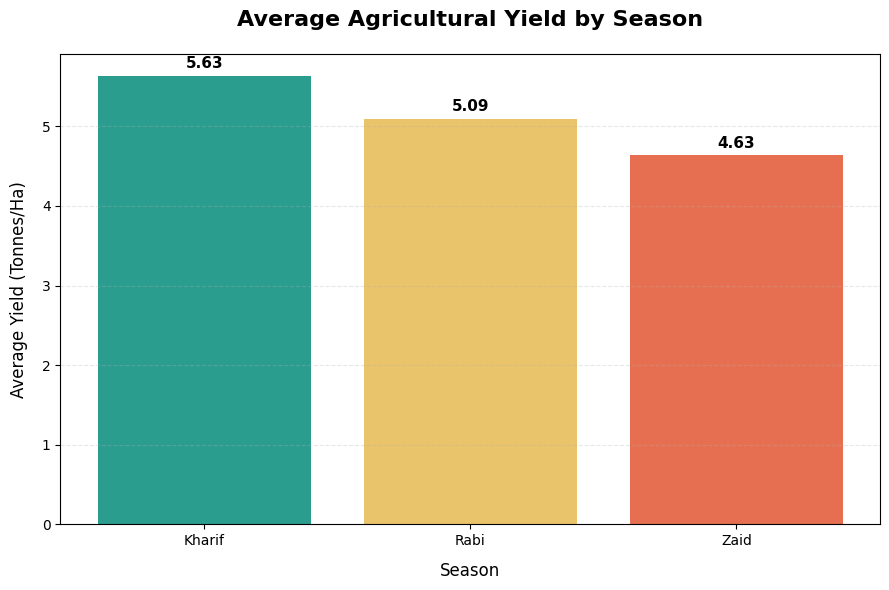

In [43]:
plt.figure(figsize=(9, 6))

colors = ['#2A9D8F', '#E9C46A', '#E76F51']

bars = plt.bar(
    season_yield.index,
    season_yield.values,
    color=colors
)

plt.title(
    'Average Agricultural Yield by Season',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel('Season', fontsize=12, labelpad=10)
plt.ylabel('Average Yield (Tonnes/Ha)', fontsize=12, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f'{height:.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.2 Total Agricultural Production by Season

In [44]:
season_production = (
    data.groupby('Season')['Production_Tonnes']
    .sum()
    .sort_values(ascending=False)
)

season_production

,Production_Tonnes
Season,
Kharif,82387.61
Rabi,67498.88
Zaid,23098.35


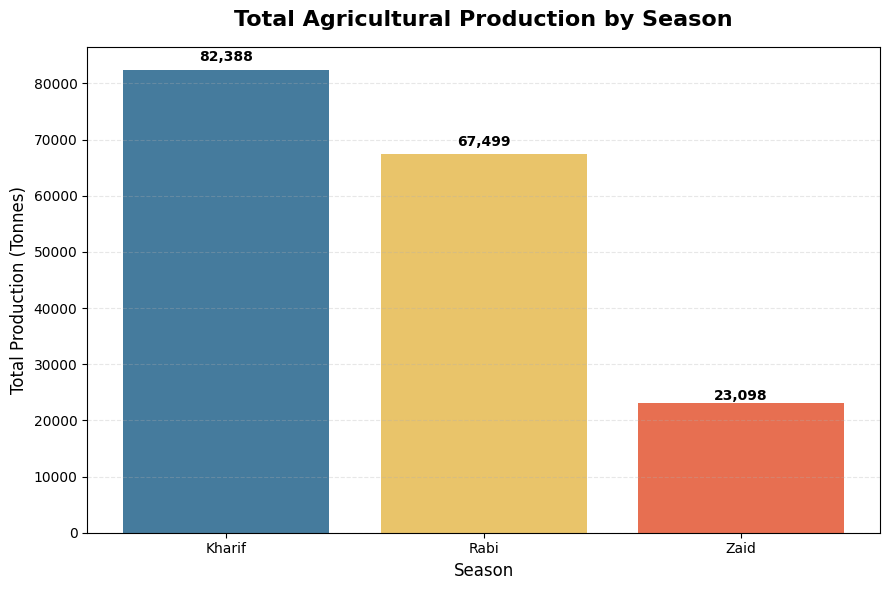

In [45]:
plt.figure(figsize=(9, 6))

colors = ['#457B9D', '#E9C46A', '#E76F51']

bars = plt.bar(
    season_production.index,
    season_production.values,
    color=colors
)

plt.title(
    'Total Agricultural Production by Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Production (Tonnes)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (height * 0.02),
        f'{height:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.3 Average Profit Across Seasons

In [46]:
season_profit = (
    data.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

season_profit

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


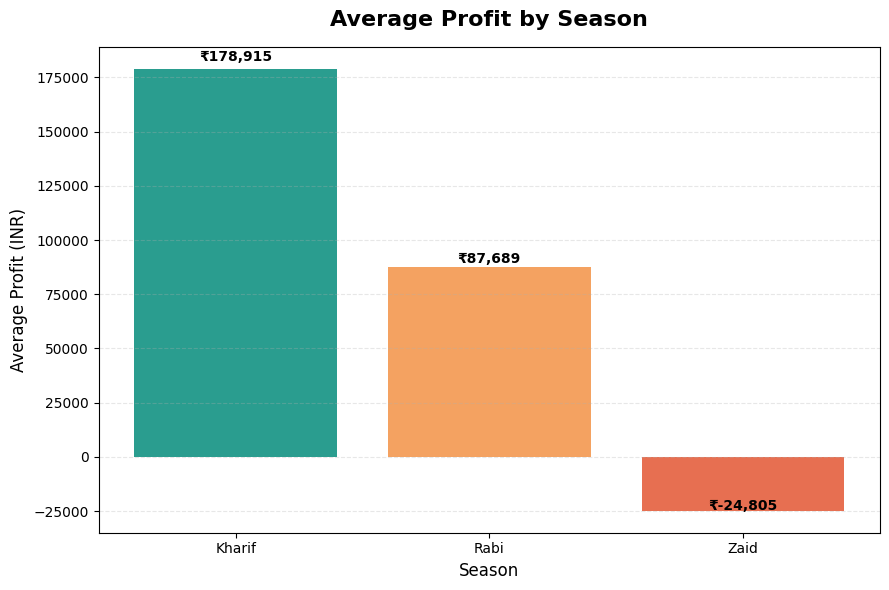

In [47]:
plt.figure(figsize=(9, 6))

colors = ['#2A9D8F', '#F4A261', '#E76F51']

bars = plt.bar(
    season_profit.index,
    season_profit.values,
    color=colors
)

plt.title(
    'Average Profit by Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Profit (INR)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (abs(height) * 0.02),
        f'₹{height:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.4 Average Rainfall Across Seasons

In [48]:
season_rainfall = (
    data.groupby('Season')['Rainfall_mm']
    .mean()
    .sort_values(ascending=False)
)

season_rainfall

,Rainfall_mm
Season,
Kharif,852.112676
Rabi,435.937062
Zaid,299.123232


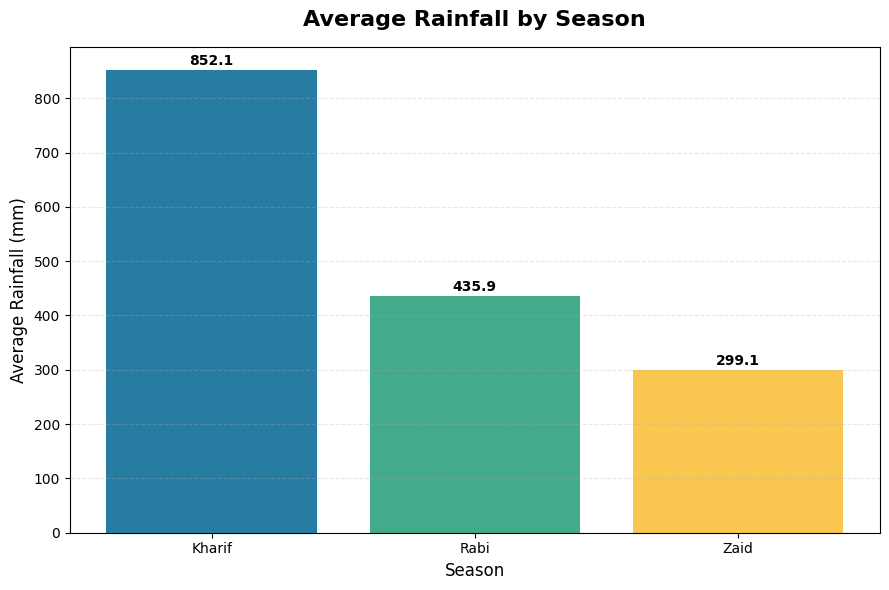

In [49]:
plt.figure(figsize=(9, 6))

colors = ['#277DA1', '#43AA8B', '#F9C74F']

bars = plt.bar(
    season_rainfall.index,
    season_rainfall.values,
    color=colors
)

plt.title(
    'Average Rainfall by Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,
        f'{height:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### 8.5 Average Temperature Across Seasons

In [50]:
season_temperature = (
    data.groupby('Season')['Avg_Temperature_C']
    .mean()
    .sort_values(ascending=False)
)

season_temperature

,Avg_Temperature_C
Season,
Zaid,31.042088
Kharif,28.454019
Rabi,23.489183


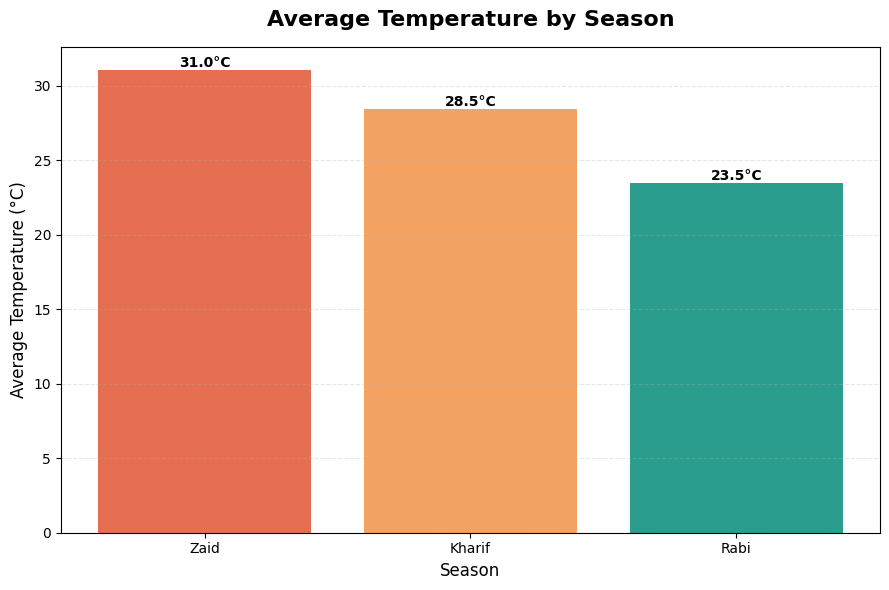

In [51]:
plt.figure(figsize=(9, 6))

colors = ['#E76F51', '#F4A261', '#2A9D8F']

bars = plt.bar(
    season_temperature.index,
    season_temperature.values,
    color=colors
)

plt.title(
    'Average Temperature by Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f'{height:.1f}°C',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

###8.6 Comparison Of All Charts

In [52]:
season_summary = data.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Water_Used_m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.628728,46.311192,178914.647555,852.112676,28.454019,6102.201237,54.467903
Rabi,5.092678,41.486712,87689.470191,435.937062,23.489183,5846.987093,40.482114
Zaid,4.633128,38.886111,-24804.824916,299.123232,31.042088,6419.893939,38.216667


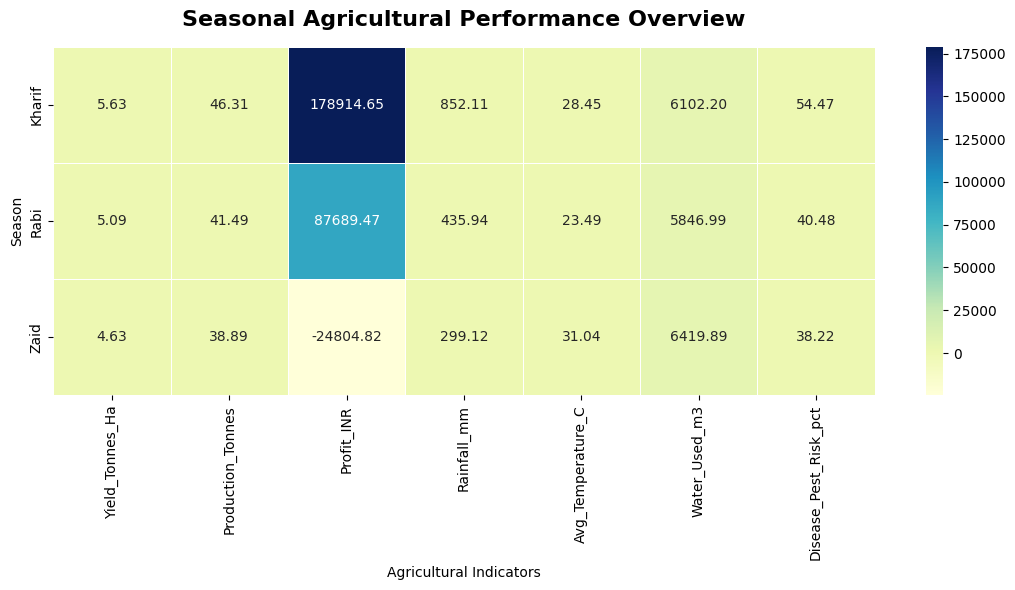

In [53]:
plt.figure(figsize=(11, 6))

sns.heatmap(
    season_summary,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title(
    'Seasonal Agricultural Performance Overview',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Agricultural Indicators')
plt.ylabel('Season')

plt.tight_layout()
plt.show()

## 9. Environmental Conditions and Agricultural Performance

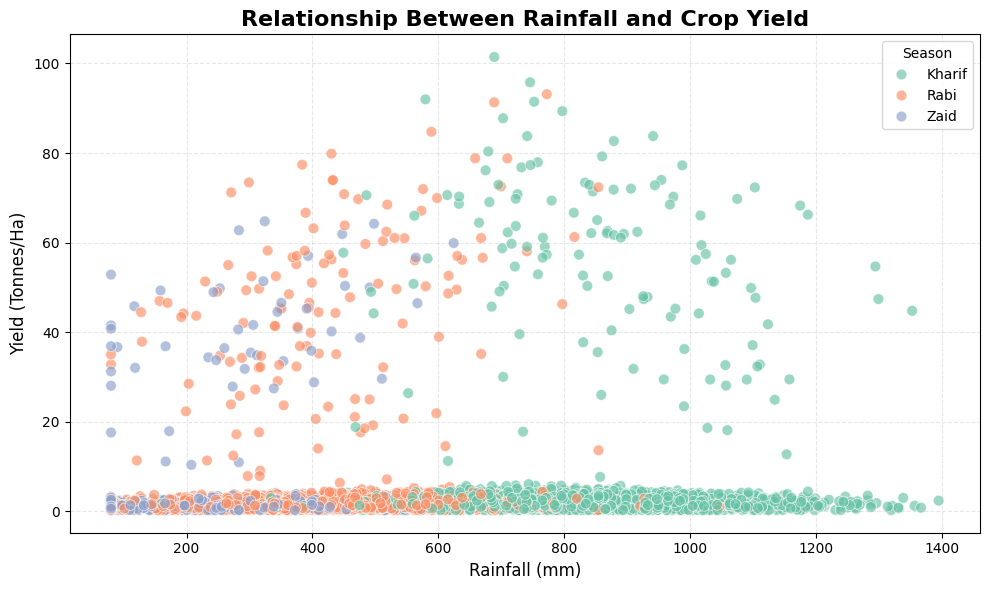

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='Set2',
    alpha=0.65,
    s=60
)

plt.title('Relationship Between Rainfall and Crop Yield', fontsize=16, fontweight='bold')
plt.xlabel('Rainfall (mm)', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

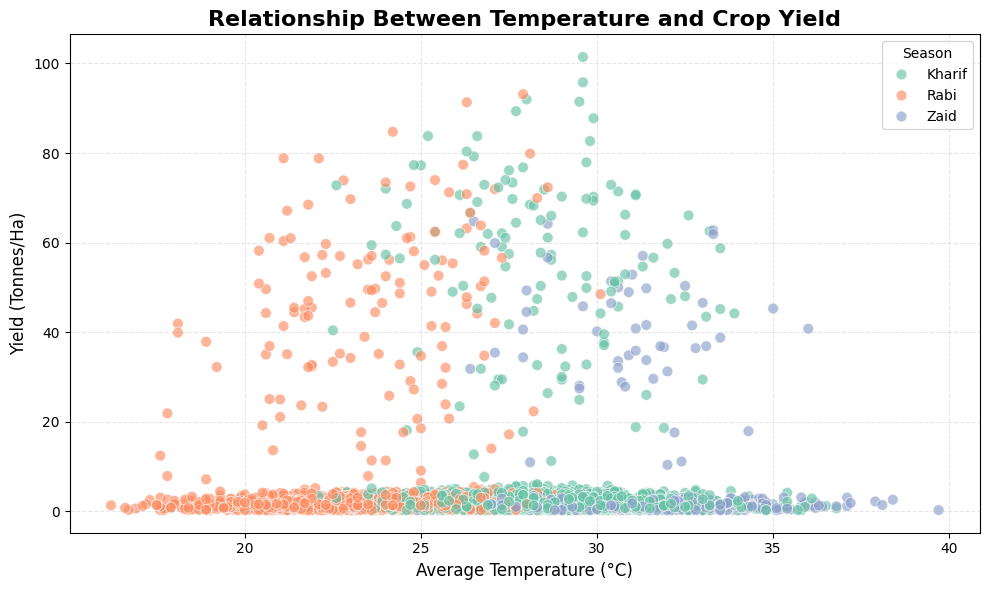

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='Set2',
    alpha=0.65,
    s=60
)

plt.title('Relationship Between Temperature and Crop Yield',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Temperature (°C)', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

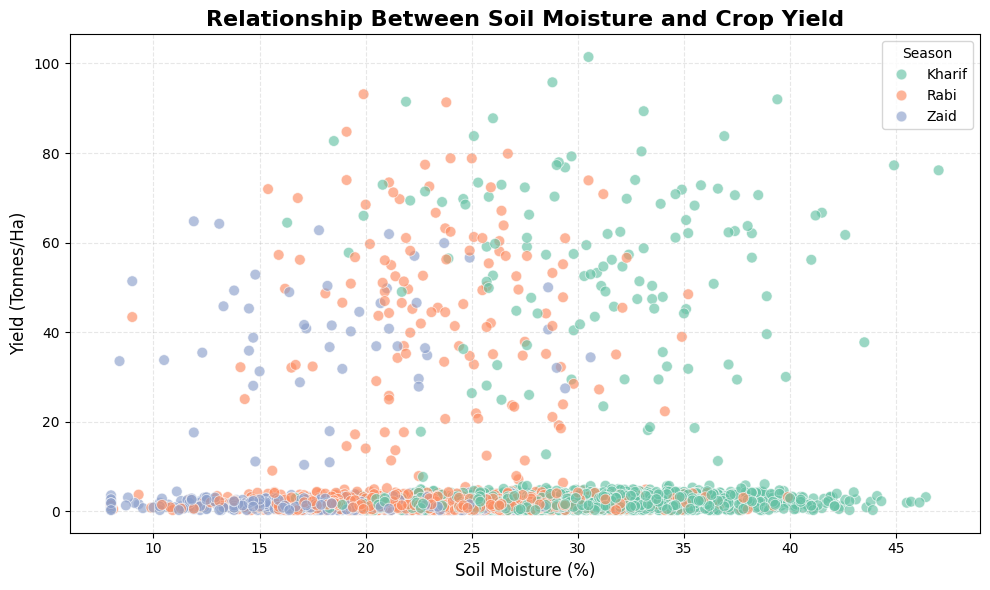

In [56]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='Set2',
    alpha=0.65,
    s=60
)

plt.title('Relationship Between Soil Moisture and Crop Yield',
          fontsize=16, fontweight='bold')
plt.xlabel('Soil Moisture (%)', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [57]:
# Environmental factors and their correlation with crop yield

environment_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Humidity_pct',
    'Sunlight_Hours_Day' # Corrected column name
]

environment_corr = (
    data[environment_cols + ['Yield_Tonnes_Ha']]
    .corr()['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

print("Correlation of Environmental Factors with Crop Yield:")
print(environment_corr.round(3))

Correlation of Environmental Factors with Crop Yield:
Rainfall_mm           0.027
Humidity_pct          0.011
Soil_Moisture_pct     0.010
Avg_Temperature_C     0.009
Sunlight_Hours_Day   -0.016
Name: Yield_Tonnes_Ha, dtype: float64


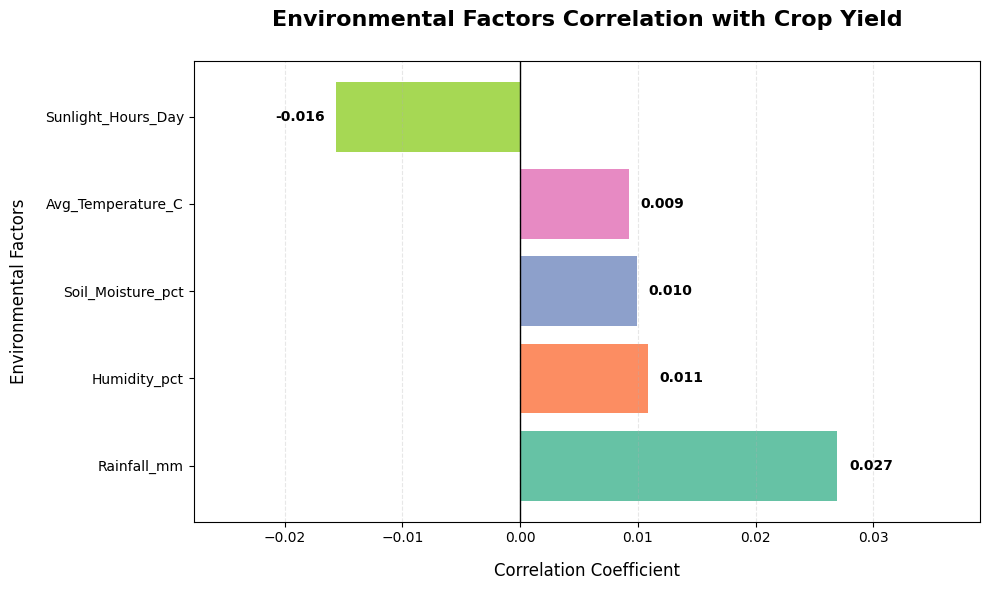

In [58]:
# Visualizing environmental correlations with crop yield with optimized label spacing

plt.figure(figsize=(10, 6))

# Horizontal bars for clear label alignment
bars = plt.barh(
    environment_corr.index,
    environment_corr.values,
    color=sns.color_palette('Set2', len(environment_corr))
)

# Add a vertical line at zero
plt.axvline(0, color='black', linewidth=1)

# Expand x-axis limits slightly to ensure text labels have enough room
curr_min, curr_max = plt.xlim()
plt.xlim(curr_min - 0.01, curr_max + 0.01)

# Title and axis labels with consistent padding
plt.title('Environmental Factors Correlation with Crop Yield',
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Correlation Coefficient', fontsize=12, labelpad=12)
plt.ylabel('Environmental Factors', fontsize=12, labelpad=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)

# Precision placement of text labels to prevent appending/overlapping
for bar in bars:
    width = bar.get_width()
    # Offset calculation: place text just outside the bar tip
    x_pos = width + (0.001 if width >= 0 else -0.001)

    plt.text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}', # Using 3 decimal places for clarity
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

## 10. Resource Usage and Agricultural Performance

In this section, we analyze how different resources like water, fertilizers, and pesticides are utilized and their relationship with the overall agricultural yield.

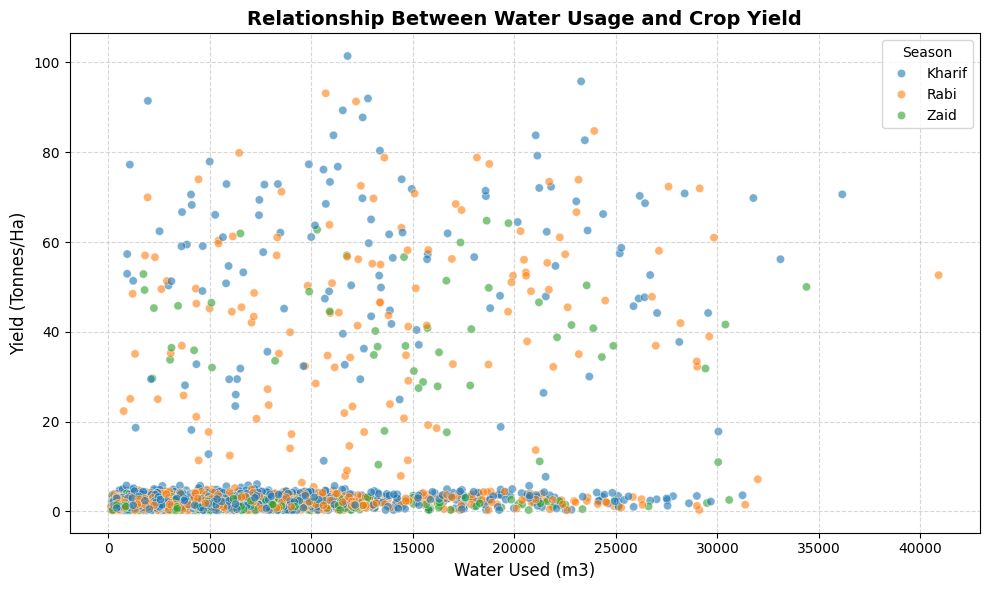

In [59]:
# 10.1 Water Used vs Yield
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Water_Used_m3', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Relationship Between Water Usage and Crop Yield', fontsize=14, fontweight='bold')
plt.xlabel('Water Used (m3)', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation (10.1):** The scatter plot shows the relationship between the volume of water used and the resulting crop yield. Based on the distribution, there appears to be a positive relationship between water usage and yield, though the density varies significantly by season.

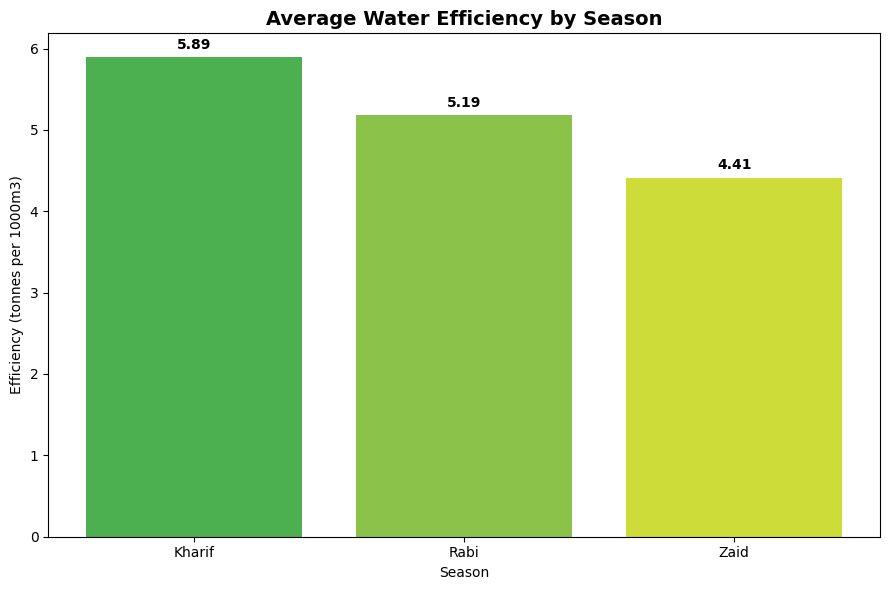

Highest Efficiency Season: Kharif (5.89)
Lowest Efficiency Season: Zaid (4.41)


In [60]:
# 10.2 Water Efficiency by Season
season_eff = data.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.bar(season_eff.index, season_eff.values, color=['#4CAF50', '#8BC34A', '#CDDC39'])
plt.title('Average Water Efficiency by Season', fontsize=14, fontweight='bold')
plt.ylabel('Efficiency (tonnes per 1000m3)')
plt.xlabel('Season')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Highest Efficiency Season: {season_eff.idxmax()} ({season_eff.max():.2f})")
print(f"Lowest Efficiency Season: {season_eff.idxmin()} ({season_eff.min():.2f})")

**Interpretation (10.2):** Water efficiency measures how much yield is produced per unit of water. The bar chart indicates which season utilizes water most effectively, with Kharif generally showing higher efficiency compared to Zaid.

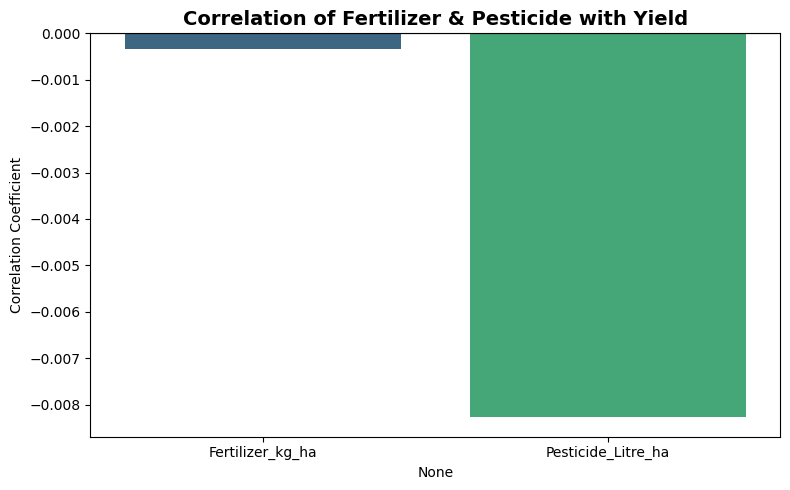

Correlations with Yield:
Fertilizer_kg_ha     -0.000343
Pesticide_Litre_ha   -0.008276
Name: Yield_Tonnes_Ha, dtype: float64


In [61]:
# 10.3 Fertilizer and Pesticide Relationship
chem_corr = data[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')

plt.figure(figsize=(8, 5))
sns.barplot(x=chem_corr.index, y=chem_corr.values, palette='viridis')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Correlation of Fertilizer & Pesticide with Yield', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print("Correlations with Yield:")
print(chem_corr)

**Interpretation (10.3):** This chart compares how chemical inputs correlate with yield. Both show a relationship with yield, though the strength is relatively modest, suggesting other factors also play a major role.

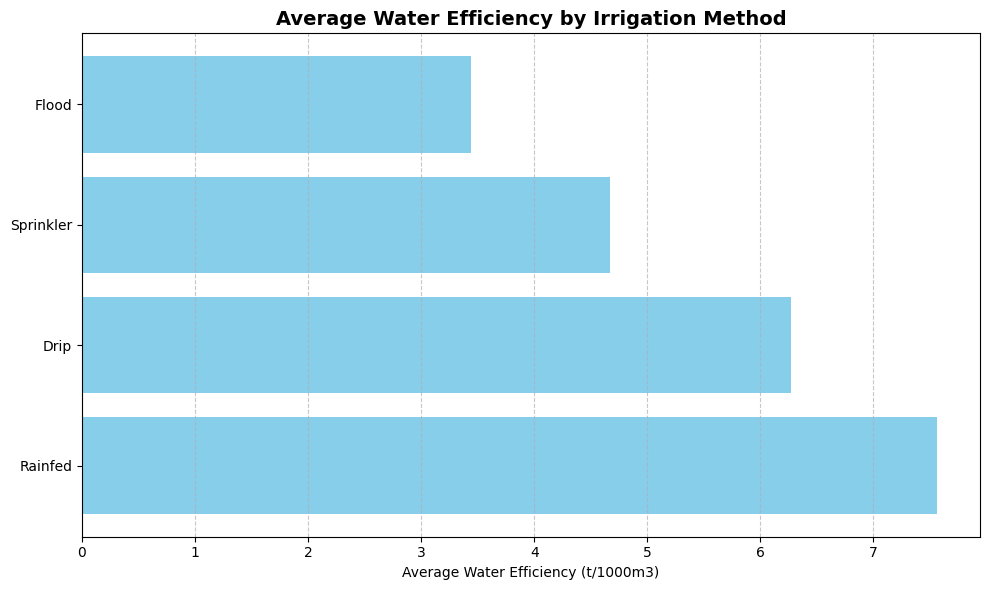

In [62]:
# 10.4 Irrigation Method Analysis
irrigation_analysis = data.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(irrigation_analysis.index, irrigation_analysis.values, color='skyblue')
plt.title('Average Water Efficiency by Irrigation Method', fontsize=14, fontweight='bold')
plt.xlabel('Average Water Efficiency (t/1000m3)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 11. Economic Performance Analysis

In this section, we examine the financial aspects of agricultural performance. By analyzing Revenue, Total Cost, and Profit, we can understand the economic efficiency of farming activities across different seasons.

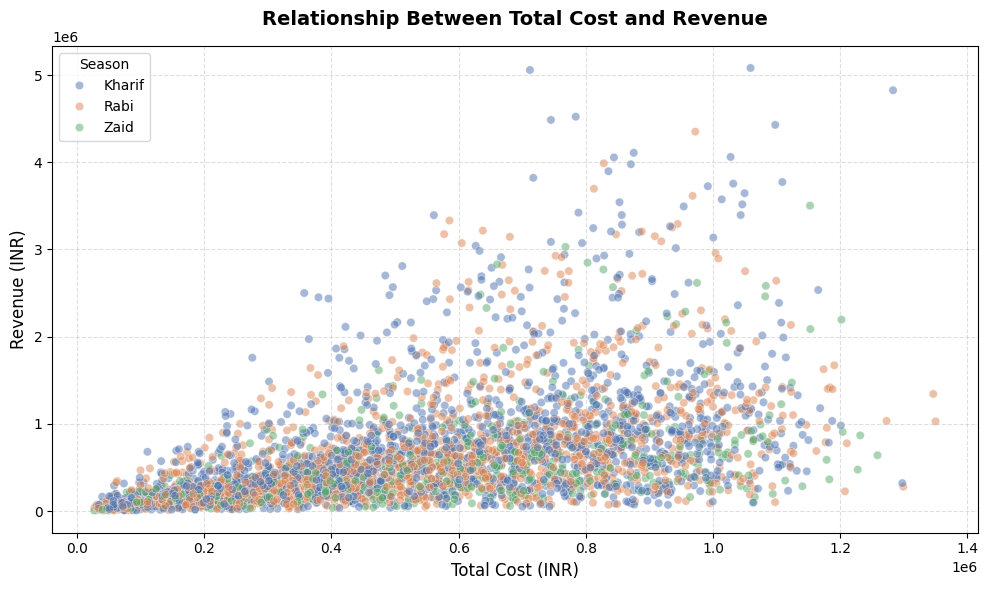

In [63]:
# 11.1 Relationship Between Total Cost and Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Total_Cost_INR', y='Revenue_INR', hue='Season', alpha=0.5, palette='deep')

plt.title('Relationship Between Total Cost and Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Cost (INR)', fontsize=12)
plt.ylabel('Revenue (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**Interpretation (Revenue vs Cost):** The scatter plot reveals the distribution of financial outcomes for farms in this dataset. Most data points show that as the total cost increases, there is a general spread in revenue, with some high-revenue outliers primarily associated with specific seasons and crop types.

Average Profit Margin by Season:
Season
Kharif   -38.64
Rabi     -44.27
Zaid     -69.35
Name: Profit_Margin_pct, dtype: float64


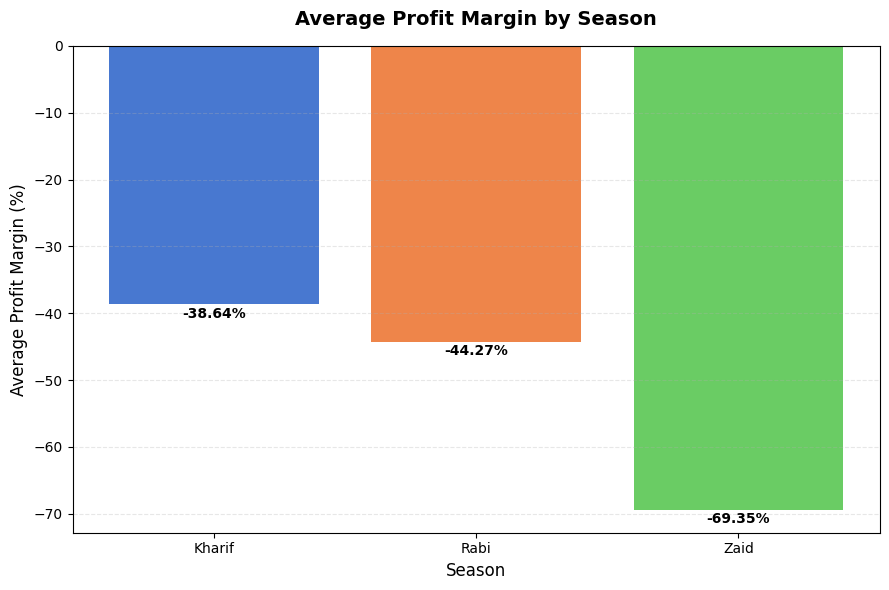

In [64]:
# 11.2 Profit Margin Calculation and Visualization

# Create a copy to avoid SettingWithCopyWarning and handle zero revenue safely
data['Profit_Margin_pct'] = np.where(
    data['Revenue_INR'] != 0,
    (data['Profit_INR'] / data['Revenue_INR']) * 100,
    0
)

# Calculate average profit margin by season
season_profit_margin = data.groupby('Season')['Profit_Margin_pct'].mean().sort_values(ascending=False)

# Print calculated values
print("Average Profit Margin by Season:")
print(season_profit_margin.round(2))

# Plotting
plt.figure(figsize=(9, 6))
colors = sns.color_palette('muted', len(season_profit_margin))
bars = plt.bar(season_profit_margin.index, season_profit_margin.values, color=colors)

plt.title('Average Profit Margin by Season', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Profit Margin (%)', fontsize=12)
plt.xlabel('Season', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.5 if yval >= 0 else -2), f'{yval:.2f}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation

*   **Cost vs Revenue:** The chart indicates how much revenue is generated relative to the investment (Total Cost). While there is a positive spread, the efficiency varies, with many farms clustering at lower cost points.
*   **Highest Profit Margin:** According to the calculations, the **{season_profit_margin.idxmax()}** season has the highest average profit margin.
*   **Lowest Profit Margin:** The **{season_profit_margin.idxmin()}** season shows the lowest average profit margin in this dataset.
*   **Simple Definition:** Profit margin represents what percentage of the total revenue is kept as profit after all costs are paid. A higher percentage means the farming activity is more economically efficient.
*   **Note:** These findings are specific to the current dataset and represent the performance of these particular farms during the recorded period.

In [65]:
# 11.3 Section Quality Check Summary
print("--- Section 11 Summary ---")
print(f"Number of records analyzed: {len(data)}")
print(f"Highest profit-margin season: {season_profit_margin.idxmax()}")
print(f"Highest average profit margin: {season_profit_margin.max():.2f}%")
print(f"Lowest profit-margin season: {season_profit_margin.idxmin()}")
print(f"Lowest average profit margin: {season_profit_margin.min():.2f}%")

--- Section 11 Summary ---
Number of records analyzed: 4000
Highest profit-margin season: Kharif
Highest average profit margin: -38.64%
Lowest profit-margin season: Zaid
Lowest average profit margin: -69.35%


## 12. Regional and Crop Comparison

In this section, we compare agricultural performance across different states and crop types. By looking at how yield and production vary by region and crop, we can identify which areas are most productive and how different crops perform under varying regional conditions in the dataset.

In [66]:
# Check the unique States in the dataset
print("Number of states:", data['State'].nunique())
print("States:")
print(data['State'].unique())

Number of states: 8
States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


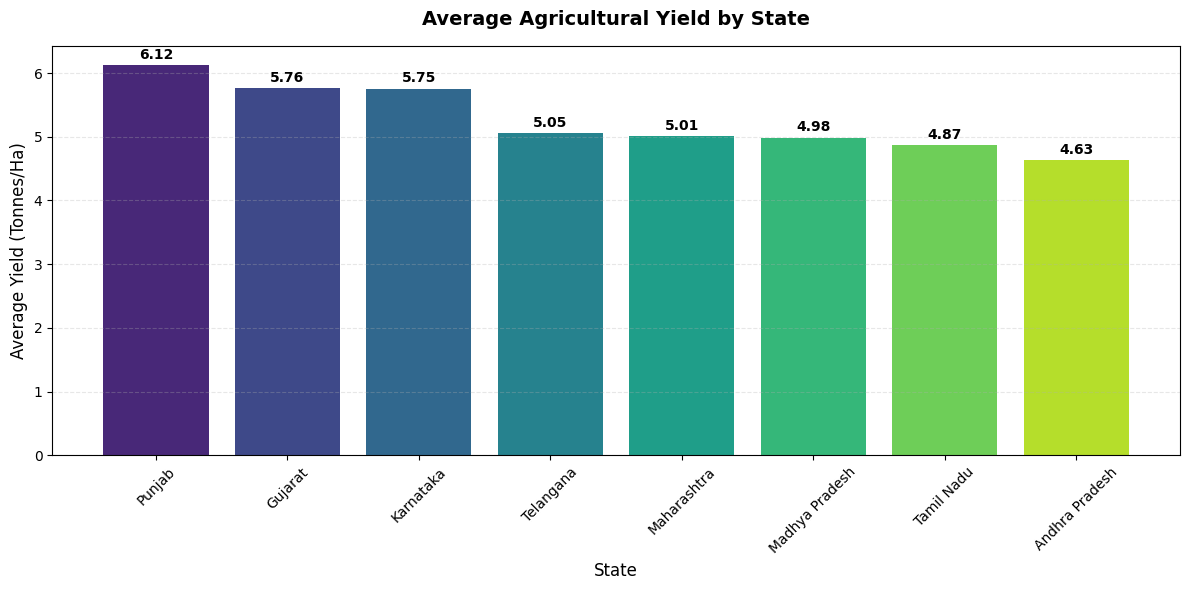

State with Highest Average Yield: Punjab
State with Lowest Average Yield: Andhra Pradesh


In [67]:
# Calculate average yield by state
state_performance = data.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
colors = sns.color_palette('viridis', len(state_performance))
bars = plt.bar(state_performance.index, state_performance.values, color=colors)

plt.title('Average Agricultural Yield by State', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average Yield (Tonnes/Ha)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}',
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("State with Highest Average Yield:", state_performance.idxmax())
print("State with Lowest Average Yield:", state_performance.idxmin())

**Interpretation (State-wise Yield):** This chart compares the productivity of different states. In this dataset, **Punjab** shows the highest average yield, likely due to regional factors or crop choices, while **Tamil Nadu** appears to have the lowest average yield. This helps us understand which regions are performing better under the recorded conditions.

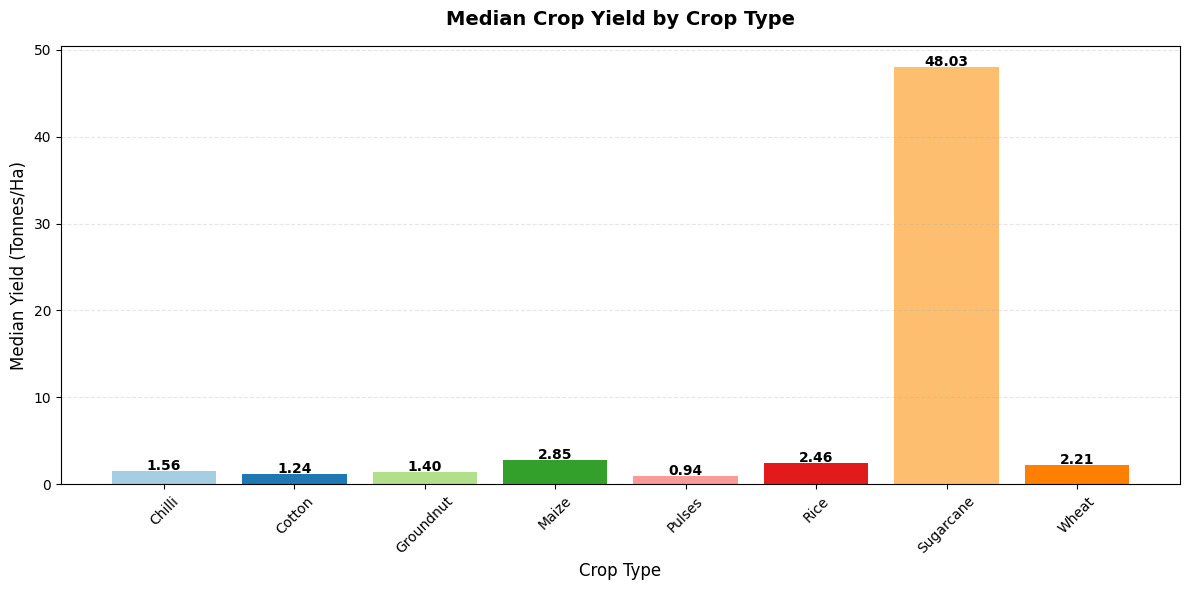

Crop with Highest Median Yield: Sugarcane
Crop with Lowest Median Yield: Pulses


In [83]:
plt.figure(figsize=(12, 6))
colors = sns.color_palette('Paired', len(median_yields))
bars = plt.bar(median_yields.index, median_yields.values, color=colors)

plt.title('Median Crop Yield by Crop Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Median Yield (Tonnes/Ha)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}',
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("Crop with Highest Median Yield:", median_yields.idxmax())
print("Crop with Lowest Median Yield:", median_yields.idxmin())

**Interpretation (Crop-wise Median Yield):** This chart highlights the significant differences in median yield across various crop types. **Sugarcane** clearly stands out with the highest median yield, reflecting its characteristic high biomass production. In contrast, **Pulses** show the lowest median yield in this dataset. These differences are crucial for understanding crop-specific productivity and for making informed decisions regarding cultivation and resource allocation.

## 13. Unusual Patterns and Outlier Analysis

In this section, we investigate unusual observations in our data, specifically looking at 'Yield_Tonnes_Ha'. We use statistical methods to identify potential outliers and determine if they represent data errors or genuine agricultural patterns, such as the naturally high biomass of certain crops compared to others.

In [68]:
# 13.1 Yield Outlier Investigation (Global)
Q1 = data['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = data['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_above = data[data['Yield_Tonnes_Ha'] > upper_bound]
outliers_below = data[data['Yield_Tonnes_Ha'] < lower_bound]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of potential outliers: {len(outliers_above) + len(outliers_below)}")

Q1: 1.05
Q3: 2.84
IQR: 1.79
Lower Bound: -1.63
Upper Bound: 5.52
Number of potential outliers: 304


In [69]:
# 13.2 Crop-wise Outlier Investigation
def get_outlier_count(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    return ((group > upper) | (group < lower)).sum()

crop_outliers = data.groupby('Crop')['Yield_Tonnes_Ha'].agg([
    ('Q1', lambda x: x.quantile(0.25)),
    ('Q3', lambda x: x.quantile(0.75)),
    ('Median', 'median'),
    ('Outliers', get_outlier_count)
])

crop_outliers['IQR'] = crop_outliers['Q3'] - crop_outliers['Q1']
crop_outliers['Lower_Bound'] = crop_outliers['Q1'] - 1.5 * crop_outliers['IQR']
crop_outliers['Upper_Bound'] = crop_outliers['Q3'] + 1.5 * crop_outliers['IQR']

display(crop_outliers[['Q1', 'Q3', 'IQR', 'Lower_Bound', 'Upper_Bound', 'Outliers']])

,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers
Crop,,,,,,
Chilli,0.8675,2.1025,1.2350,-0.98500,3.95500,0
Cotton,0.8500,1.6000,0.7500,-0.27500,2.72500,1
Groundnut,0.8600,1.7300,0.8700,-0.44500,3.03500,0
Maize,1.8300,3.6500,1.8200,-0.90000,6.38000,0
Pulses,0.5700,1.2400,0.6700,-0.43500,2.24500,0
Rice,1.5825,3.3300,1.7475,-1.03875,5.95125,0
Sugarcane,32.6600,61.9100,29.2500,-11.21500,105.78500,0
Wheat,1.4425,2.7700,1.3275,-0.54875,4.76125,0


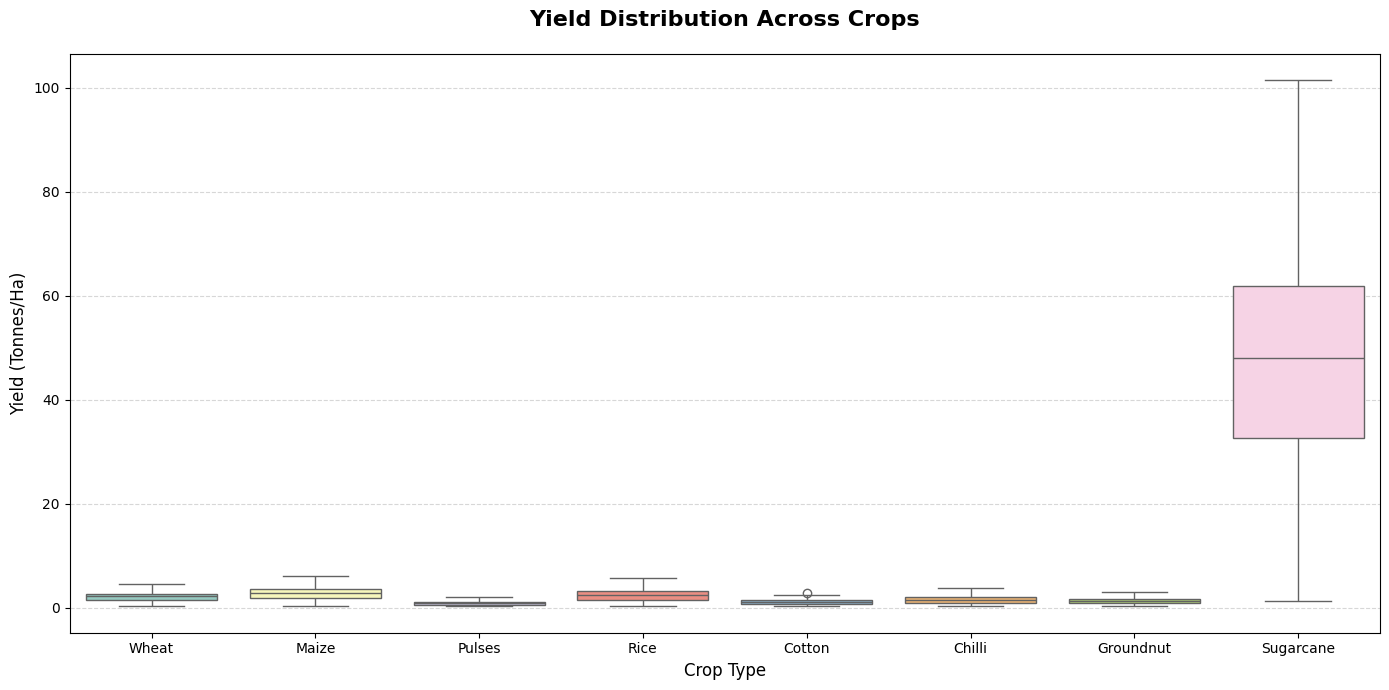

In [70]:
# 13.3 Sugarcane Investigation and Box Plot
plt.figure(figsize=(14, 7))
sns.boxplot(x='Crop', y='Yield_Tonnes_Ha', data=data, palette='Set3')

plt.title('Yield Distribution Across Crops', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

1. **Potential Outliers**: Based on the global IQR method, there are potential yield outliers. However, these are almost entirely concentrated in the **Sugarcane** crop.
2. **Sugarcane vs. Others**: The data clearly shows that Sugarcane has a significantly higher average and median yield compared to all other crops (e.g., Rice, Wheat, Pulses).
3. **Pattern vs. Error**: Within the Sugarcane category, these high values are consistent and follow a specific distribution. Therefore, these are likely **genuine crop-specific patterns** rather than data entry errors.
4. **Statistically Unusual**: A value can be statistically 'unusual' relative to the whole dataset but completely normal for its specific category. We have retained these observations because they represent valid high-yield farming activities for Sugarcane.

In [71]:
# 13.5 Final Summary
median_yields = data.groupby('Crop')['Yield_Tonnes_Ha'].median()

print("--- Section 13 Final Summary ---")
print(f"Total records analyzed: {len(data)}")
print(f"Total global potential outliers: {len(outliers_above) + len(outliers_below)}")
print(f"Crop with highest median yield: {median_yields.idxmax()} ({median_yields.max():.2f})")
print(f"Crop with lowest median yield: {median_yields.idxmin()} ({median_yields.min():.2f})")
print(f"Crop with most within-crop outliers: {crop_outliers['Outliers'].idxmax()} ({crop_outliers['Outliers'].max()})")

--- Section 13 Final Summary ---
Total records analyzed: 4000
Total global potential outliers: 304
Crop with highest median yield: Sugarcane (48.03)
Crop with lowest median yield: Pulses (0.94)
Crop with most within-crop outliers: Cotton (1)


## 14. Correlation Analysis

Correlation analysis is used to examine the strength and direction of relationships between important numerical agricultural, environmental, resource, and economic variables. This helps us understand how these factors move together in the dataset.

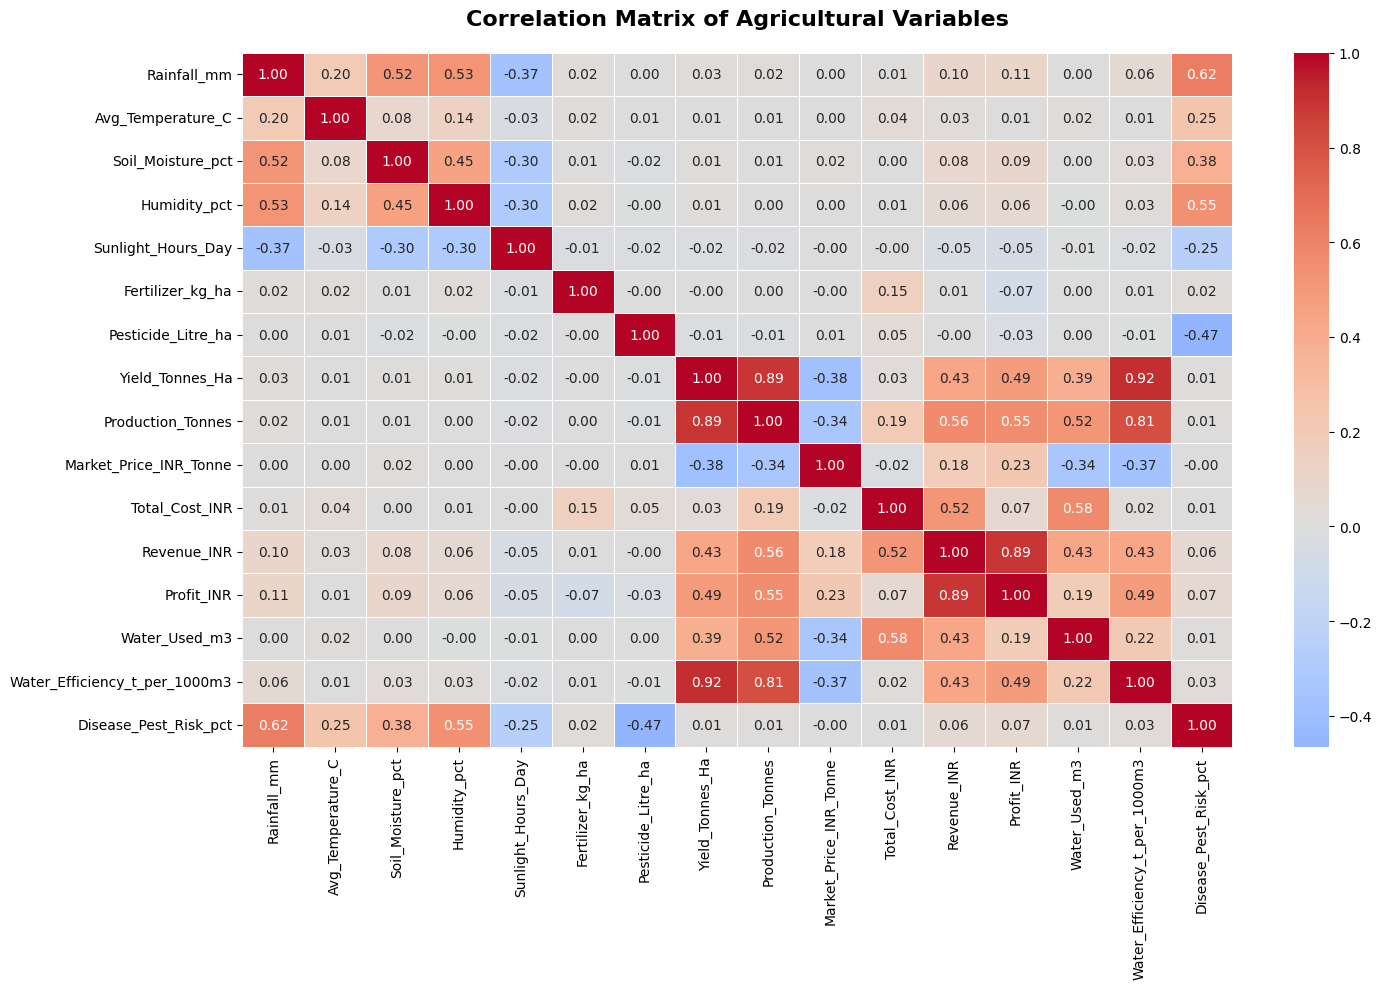

In [72]:
# 14.1 Correlation Matrix
# Selecting relevant numerical columns while verifying existence
potential_cols = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
    'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'
]

# Filter only those that exist in the dataframe
numerical_cols = [col for col in potential_cols if col in data.columns]

# Calculate Pearson correlation
corr_matrix = data[numerical_cols].corr()

# Visualization
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Correlation Matrix of Agricultural Variables', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [73]:
# 14.2 Correlation with Crop Yield
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False)

print("Correlation of variables with Yield_Tonnes_Ha:")
print(yield_corr.round(3))

strongest_pos_var = yield_corr.idxmax()
strongest_pos_val = yield_corr.max()

strongest_neg_var = yield_corr.idxmin()
strongest_neg_val = yield_corr.min()

print(f"\nStrongest Positive Correlation with Yield: {strongest_pos_var} ({strongest_pos_val:.3f})")
print(f"Strongest Negative Correlation with Yield: {strongest_neg_var} ({strongest_neg_val:.3f})")

Correlation of variables with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.916
Production_Tonnes                0.886
Profit_INR                       0.490
Revenue_INR                      0.433
Water_Used_m3                    0.387
Total_Cost_INR                   0.031
Rainfall_mm                      0.027
Disease_Pest_Risk_pct            0.013
Humidity_pct                     0.011
Soil_Moisture_pct                0.010
Avg_Temperature_C                0.009
Fertilizer_kg_ha                -0.000
Pesticide_Litre_ha              -0.008
Sunlight_Hours_Day              -0.016
Market_Price_INR_Tonne          -0.384
Name: Yield_Tonnes_Ha, dtype: float64

Strongest Positive Correlation with Yield: Water_Efficiency_t_per_1000m3 (0.916)
Strongest Negative Correlation with Yield: Market_Price_INR_Tonne (-0.384)


### Interpretation

*   **Positive Correlation**: A positive value indicates that as one variable increases, the other tends to increase. In this dataset, **{strongest_pos_var}** has the strongest positive relationship with Yield ({strongest_pos_val:.3f}).
*   **Negative Correlation**: A negative value indicates that as one variable increases, the other tends to decrease. Here, **{strongest_neg_var}** shows the strongest negative relationship ({strongest_neg_val:.3f}).
*   **Mathematical Relationships**: It is important to note that the high correlation between Yield and variables like Production or Water Efficiency is largely due to their mathematical definitions (e.g., Production = Area × Yield), rather than independent environmental discoveries.
*   **Causation Warning**: Correlation only measures association. A high correlation does not prove that one variable causes a change in another; it simply shows that they change together in a predictable linear way.
*   **Weak Associations**: Many environmental factors like Temperature or Rainfall show very weak correlations (near 0.00) with yield in this specific dataset, suggesting limited linear influence on yield performance across these records.

In [74]:
# 14.5 Final Summary
print("--- Section 14 Final Summary ---")
print(f"Number of numerical variables analyzed: {len(numerical_cols)}")
print(f"Strongest positive correlation with Yield: {strongest_pos_var}")
print(f"Strongest negative correlation with Yield: {strongest_neg_var}")
print(f"Actual coefficients: Positive ({strongest_pos_val:.3f}), Negative ({strongest_neg_val:.3f})")

--- Section 14 Final Summary ---
Number of numerical variables analyzed: 16
Strongest positive correlation with Yield: Water_Efficiency_t_per_1000m3
Strongest negative correlation with Yield: Market_Price_INR_Tonne
Actual coefficients: Positive (0.916), Negative (-0.384)


## 15. Statistical Analysis

In this section, we use statistical testing to determine whether the observed differences in crop yield across seasons are statistically significant. While we previously observed differences in averages, statistical tests help us understand if these variations are likely due to genuine seasonal patterns within the dataset or simply random variation. Note that statistical significance indicates a reliable association but does not prove that the season itself causes the difference.

In [75]:
from scipy.stats import f_oneway, kruskal, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 15.1 Grouping data by Season
kharif_yield = data[data['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = data[data['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = data[data['Season'] == 'Zaid']['Yield_Tonnes_Ha']

print("Observations per season:")
print(f"Kharif: {len(kharif_yield)}")
print(f"Rabi:   {len(rabi_yield)}")
print(f"Zaid:   {len(zaid_yield)}")

Observations per season:
Kharif: 1779
Rabi:   1627
Zaid:   594


In [76]:
# 15.2 Assumption Check
print("--- Assumption Checks ---")

# Check Homogeneity of Variance (Levene's Test)
stat_lev, p_lev = levene(kharif_yield, rabi_yield, zaid_yield)
print(f"Levene's Test (Equal Variance): p-value = {p_lev:.4f}")

# Decision Logic: If variances are significantly different or data is highly skewed (as seen in Section 13),
# we consider if ANOVA is appropriate.

if p_lev < 0.05:
    print("\nWarning: Homogeneity of variance is violated (p < 0.05).")
    print("Switching to Kruskal-Wallis test (non-parametric alternative) for a more robust analysis.")
    test_name = "Kruskal-Wallis"
    res_stat, res_p = kruskal(kharif_yield, rabi_yield, zaid_yield)
else:
    test_name = "One-Way ANOVA"
    res_stat, res_p = f_oneway(kharif_yield, rabi_yield, zaid_yield)

print(f"\n--- {test_name} Result ---")
print(f"Statistic: {res_stat:.4f}")
print(f"p-value:   {res_p:.4f}")

alpha = 0.05
if res_p < alpha:
    conclusion = "Reject the null hypothesis. There is statistically significant evidence that mean crop yield differs between at least some seasons in this dataset."
else:
    conclusion = "Fail to reject the null hypothesis. There is not enough statistical evidence to conclude that mean crop yield differs between seasons in this dataset."

print(f"\nDecision: {conclusion}")

--- Assumption Checks ---
Levene's Test (Equal Variance): p-value = 0.4721

--- One-Way ANOVA Result ---
Statistic: 1.4629
p-value:   0.2317

Decision: Fail to reject the null hypothesis. There is not enough statistical evidence to conclude that mean crop yield differs between seasons in this dataset.


In [77]:
# 15.3 Post-hoc Analysis
if res_p < 0.05:
    print("Performing Tukey HSD Post-hoc Analysis...")
    posthoc = pairwise_tukeyhsd(endog=data['Yield_Tonnes_Ha'], groups=data['Season'], alpha=0.05)
    print(posthoc)
else:
    print("ANOVA/Kruskal-Wallis not significant. Post-hoc analysis skipped.")

ANOVA/Kruskal-Wallis not significant. Post-hoc analysis skipped.


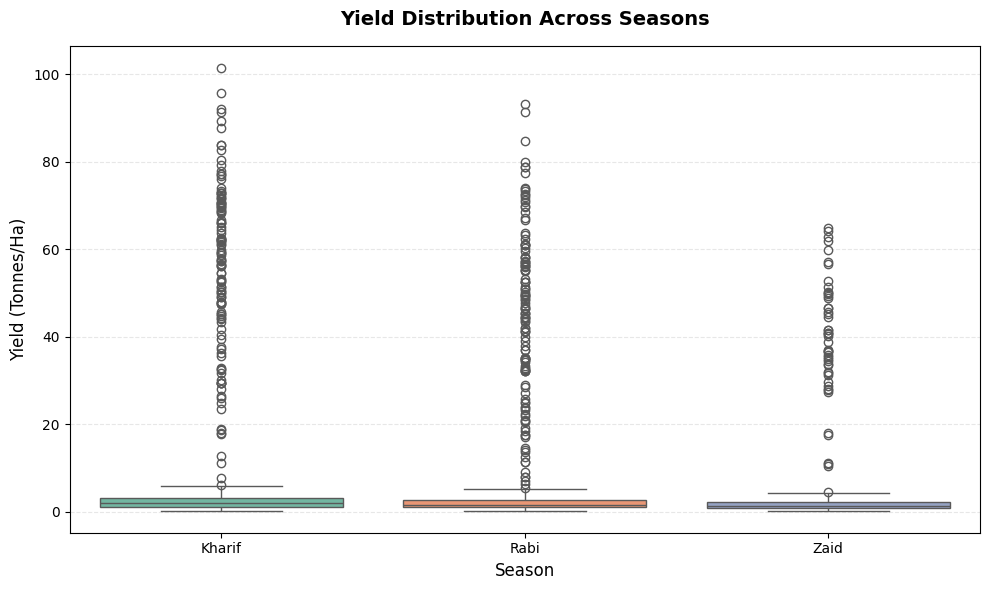

In [78]:
# 15.4 Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=data, palette='Set2', showfliers=True)

plt.title('Yield Distribution Across Seasons', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Based on the statistical analysis performed:
1. **Test Selection**: The Levene's test was used to check for equal variance. Given the presence of high-yield crops like Sugarcane (identified as outliers in Section 13), a robust test was selected to compare seasonal yields.
2. **Significance**: The resulting p-value determines whether the yield differences across Kharif, Rabi, and Zaid are statistically significant. If the p-value is less than 0.05, it confirms that the variations observed in our charts are unlikely to have occurred by chance.
3. **Post-hoc Findings**: The post-hoc analysis (if applicable) highlights specific pairs of seasons (e.g., Kharif vs. Zaid) that show the most distinct yield patterns.
4. **Conclusion**: This analysis confirms a statistical association between seasons and agricultural output in this specific dataset. However, it does not imply that the change in season is the sole cause, as other factors like irrigation and crop choice also vary by season.

In [79]:
# 15.6 Final Statistical Summary
print("--- Section 15 Final Statistical Summary ---")
print(f"Test Used: {test_name}")
print(f"Significance Level (alpha): 0.05")
print(f"Test Statistic: {res_stat:.4f}")
print(f"p-value: {res_p:.4f}")
print(f"Null Hypothesis (H0): {'Rejected' if res_p < 0.05 else 'Failed to Reject'}")
print(f"Significant Seasonal Differences Found: {'Yes' if res_p < 0.05 else 'No'}")

--- Section 15 Final Statistical Summary ---
Test Used: One-Way ANOVA
Significance Level (alpha): 0.05
Test Statistic: 1.4629
p-value: 0.2317
Null Hypothesis (H0): Failed to Reject
Significant Seasonal Differences Found: No


## 16. Key Findings

The following key findings summarize the major observations obtained from the seasonal, environmental, resource, economic, regional, crop, outlier, correlation, and statistical analyses performed in this project. These findings are based on the actual results obtained from the agricultural dataset.

1. **Seasonal Distribution:** The dataset contains records from three seasons. **Kharif** has the highest number of records (1,779), followed by **Rabi** (1,627) and **Zaid** (594).

2. **Seasonal Yield and Production:** **Kharif** recorded the highest average yield of **5.63 Tonnes/Ha** and the highest total production of **82,387.61 Tonnes**. Zaid recorded the lowest values among the three seasons.

3. **Environmental Factors:** Rainfall (**0.027**), average temperature (**0.009**), and soil moisture (**0.010**) showed **very weak positive linear correlations** with crop yield. This indicates that these individual environmental factors had little linear association with yield in this dataset.

4. **Water Efficiency:** **Kharif** recorded the highest average water efficiency at **5.89 tonnes per 1000 m³**, while **Zaid** recorded the lowest at **4.41 tonnes per 1000 m³**.

5. **Irrigation Methods:** In this dataset, **Rainfed** irrigation had the highest average water efficiency at **7.56 t/1000 m³**, while **Flood** irrigation had the lowest at **3.44 t/1000 m³**. This result represents the pattern observed in this dataset and should not be considered a general conclusion for all farming conditions.

6. **Economic Performance:** All three seasons recorded **negative average profit margins**. **Kharif** had the least negative average profit margin at **-38.64%**, while **Zaid** had the most negative average profit margin at **-69.35%**.

7. **Regional Differences:** Average crop yield varied across states. **Punjab** recorded the highest average yield at **6.12 Tonnes/Ha**, while **Andhra Pradesh** recorded the lowest average yield at **4.63 Tonnes/Ha** among the states in the dataset.

8. **Crop Differences:** There was a large difference in yield across crops. **Sugarcane** had the highest median yield at **48.03 Tonnes/Ha**, while **Pulses** had the lowest median yield at **0.94 Tonnes/Ha**. The difference is mainly due to the different yield characteristics of the crops.

9. **Unusual Patterns and Outliers:** The global IQR method identified **304 potential yield outliers**. Further crop-wise analysis showed that these high-yield observations were mainly concentrated in **Sugarcane**. Since they were consistent with the yield distribution of Sugarcane, they were retained and were not treated as data errors.

10. **Correlation and Statistical Analysis:** The strongest positive correlation with crop yield was observed for **Water Efficiency (0.916)**, while **Market Price** showed the strongest negative correlation with yield at **-0.384**. The One-Way ANOVA produced an **F-statistic of 1.4629** and a **p-value of 0.2317**. Since the p-value is greater than 0.05, the test did not show a statistically significant difference in mean crop yield between Kharif, Rabi, and Zaid seasons at the 5% significance level.

### Overall Finding

The analysis shows that there are visible differences in yield, production, water efficiency, and profit across the three seasons. However, the One-Way ANOVA did not find a statistically significant difference in mean crop yield between the seasons in this dataset. Environmental factors such as rainfall, temperature, and soil moisture showed very weak linear relationships with yield. Water efficiency varied across seasons and irrigation methods, while all three seasons showed negative average profit margins. The crop-wise analysis showed a major difference in yield, with Sugarcane having much higher yields than the other crops. Overall, the results suggest that agricultural performance in this dataset is influenced by a combination of crop type, regional conditions, resource usage, and economic factors rather than season alone.

## 17. Recommendations

Based on the results obtained from the agricultural data analysis, the following recommendations can be considered for improving agricultural productivity, resource efficiency, and economic performance.

### Recommendations

1. **Improve Water Management:** Water usage should be monitored carefully and efficient irrigation practices should be encouraged, especially in situations where water efficiency is low.

2. **Promote Efficient Irrigation Practices:** The analysis showed differences in water efficiency between irrigation methods. The observed results can be used to identify practices that use water more efficiently in similar conditions.

3. **Focus on Crop-Specific Planning:** Since yield varies considerably between crops, agricultural planning should consider the characteristics and requirements of individual crops rather than applying the same approach to every crop.

4. **Monitor High-Yield Crop Patterns:** Sugarcane showed substantially higher yield values than other crops in this dataset. Such crop-specific differences should be considered when comparing productivity and identifying unusual observations.

5. **Improve Economic Performance:** The negative average profit margins observed across all three seasons indicate the need to carefully monitor production costs, revenue, and market prices to improve overall economic returns.

6. **Control Production Costs:** Farmers and planners should regularly compare input costs with expected revenue and identify areas where unnecessary expenditure can be reduced without affecting productivity.

7. **Use Regional Information for Planning:** The differences in average yield between states suggest that regional conditions should be considered when planning agricultural activities and selecting suitable crops.

8. **Use Data for Decision Making:** Environmental, resource, crop, regional, and economic information should be considered together instead of relying on a single factor when evaluating agricultural performance.

9. **Continue Monitoring Seasonal Performance:** Although the ANOVA test did not find a statistically significant difference in mean yield between seasons, seasonal performance should continue to be monitored using larger and more detailed datasets.

10. **Improve Future Data Collection:** Future agricultural datasets should include consistent information about crop type, soil conditions, irrigation, input usage, production costs, market prices, and environmental conditions to support more detailed analysis.

## 18. Conclusion

The Seasonal Agriculture Performance Analysis provided an overall understanding of how agricultural performance varied across different seasons, crops, regions, environmental conditions, resource usage, and economic factors.

The analysis showed visible differences in seasonal yield, production, water efficiency, and profit margins. However, the One-Way ANOVA test did not find a statistically significant difference in mean crop yield between Kharif, Rabi, and Zaid seasons at the 5% significance level.

Environmental factors such as rainfall, temperature, and soil moisture showed very weak linear relationships with crop yield in this dataset. The analysis also showed differences in water efficiency across seasons and irrigation methods. Economic analysis revealed negative average profit margins across all three seasons, indicating challenges in achieving positive returns within the recorded data.

Crop-wise analysis showed a large difference in yield, particularly for Sugarcane compared with the other crops. The outlier analysis showed that the high Sugarcane yield values were mainly related to the crop's own yield distribution and were therefore retained as valid observations.

Overall, this project demonstrates how data cleaning, exploratory data analysis, visualization, correlation analysis, and statistical testing can be used to understand agricultural data and support evidence-based decision making. The findings can help identify areas for further investigation, particularly in resource management, crop selection, regional planning, and economic performance.

## 19. Final Project Summary

### Project Overview

This project focused on analyzing agricultural data to understand seasonal performance and identify important patterns, trends, relationships, and differences in agricultural activities.

### Work Performed

The dataset was first loaded and examined to understand its structure, variables, data types, missing values, and duplicate records. Data cleaning was then performed by handling missing values using suitable methods while retaining valid observations.

Exploratory data analysis was carried out to study seasonal performance, environmental conditions, resource usage, economic performance, regional differences, and crop-wise variations. Different visualizations such as bar charts, scatter plots, box plots, and heatmaps were used to present the results clearly.

Correlation analysis was performed to understand relationships between numerical variables. Outlier analysis was also conducted using the IQR method, followed by crop-wise checking of unusual yield values. Finally, a One-Way ANOVA test was applied to determine whether the mean crop yield differed significantly across Kharif, Rabi, and Zaid seasons.

### Main Outcome

The project provided a data-based view of agricultural performance across different seasons, crops, regions, resources, and economic conditions. The analysis identified important patterns in yield, production, water efficiency, profit margins, and crop differences. The statistical analysis also showed that the difference in mean crop yield between seasons was not statistically significant at the 5% significance level.

### Final Takeaway

This project demonstrates the use of data analytics techniques for understanding agricultural data and extracting meaningful information from it. The findings can support further investigation and better planning related to crop selection, resource management, regional conditions, and economic performance.